# EE675A - Assignment 1

**Name:**  Tejas Ramakrishnan<br />
**Roll No:** 201050
***
## Instructions

- **Release Date**: **21st Jan 2024**  
- **Deadline**: **Part B : 4th Feb 2024 11:59PM**
- Kindly name your submission files as `RollNo_Name_A1_PartB.ipynb`, based on the part you are submitting. Marks will be deducted for all submissions that do not follow the naming guidelines. <br />
- You are required to work out your answers and submit only the iPython Notebook. The code should be well commented and easy to understand as there are marks for this. This notebook can be used as a template for assignment submission. <br />
- Submissions are to be made through HelloIITK portal. Submissions made through mail will not be graded.<br />
- Answers to the theory questions if any should be included in the notebook itself. While using special symbols use the $\LaTeX$ mode <br />
- Make sure your plots are clear and have title, legends and clear lines, etc. <br />
- Plagiarism of any form will not be tolerated. If your solutions are found to match with other students or from other uncited sources, there will be heavy penalties and the incident will be reported to the disciplinary authorities. <br />
- In case you have any doubts, feel free to reach out to TAs for help. <br />

***
## Introduction

You are free to use parts of the given code but may also choose to write the whole thing on your own.  
The illustrations for Part-B are adapted from [Alejandro's blog post](https://medium.com/@alejandro.aristizabal24/understanding-reinforcement-learning-hands-on-part-2-multi-armed-bandits-526592072bdc) on Multi-Armed Bandits. Throughout the course we will be using the [Gymnasium toolkit](https://gymnasium.farama.org/index.html) for the assignements so before starting you may want to go through the [basic usage](https://gymnasium.farama.org/content/basic_usage/) and basics of gymnasium and the installation procedure.

I have reused the code that has been given. The answers for my code is below the pre-given code

***
# Part B: Multi-armed bandits
## Demo and Preliminaries

We will begin by getting familiar with the basic problem setup before we dig in to the actual assignement problems. Let's start by loading all the required libraries for this notebook. For generating plots you must have `ipympl` installed and `jupyter-matplotlib` extension installed and enabled.

In [16]:
# Import necessary libraries
!python.exe -m pip install --upgrade pip
!pip install "gymnasium"
!pip install ipympl
!pip install matplotlib
!pip install tqdm
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import gymnasium as gym
from tqdm import tqdm
import time

zsh:1: command not found: python.exe


The code given below is an implementation of bernoulli random variable which is used later to create a multi-arm bandit environment with bernoulli sampling. 

In [17]:
import numpy as np

def bernoulli_sample(mean, size=1):
    """
    Sample from a Bernoulli distribution with a given mean.

    Parameters:
    - mean: The probability of success (mean of the distribution).
    - size: Number of samples to generate (default is 1).

    Returns:
    - ndarray: An array of binary outcomes (0 or 1).
    """
    # Generate random samples
    samples = np.random.rand(size) < mean
    
    return samples.astype(int)

def count_percentage_of_ones(samples):
    """
    Count the percentage of 1's in the given binary samples.

    Parameters:
    - samples: An array of binary outcomes (0 or 1).

    Returns:
    - float: The percentage of 1's in the samples.
    """
    # Calculate the mean, which represents the percentage of 1's
    percentage_of_ones = np.mean(samples) * 100
    
    return percentage_of_ones

# Example usage:
mean_probability = 0.7
num_samples = 100000

samples = bernoulli_sample(mean_probability, num_samples)
percentage_ones = count_percentage_of_ones(samples)
print("Percentage of 1's in samples: {:.2f}%".format(percentage_ones))


Percentage of 1's in samples: 70.13%


The two functions below are taken from the code that was provided

In [18]:
def inc_avg(prev_avg, new_val, n):
    return prev_avg + 1/n*(new_val - prev_avg)

# Obtain the previous average
vals = np.array([4.5, 5.04, 5.32, 4.8, 5.11])
prev_avg = vals.mean()

# Calculate a new average using the incremental average update function
new_val = 5.18
new_avg = inc_avg(prev_avg, new_val, 6)

# Calculate the same average using all previous values for comparison
avg = np.append(vals, new_val).mean()

print("Average obtained from incremental update rule: ", new_avg)
print("Average obtained from basic average function:  ", avg)

Average obtained from incremental update rule:  4.991666666666666
Average obtained from basic average function:   4.991666666666666


In [19]:
def argmax(q_values):
    """
    Takes in a matrix of n*k q_values and returns the index
    of the item with the highest value for each row.
    Breaks ties randomly.
    returns: vector of size n, where each item is the index of
    the highest value in q_values for each row.
    """
    # Generate a mask of the max values for each row
    mask = q_values == q_values.max(axis=1)[:, None]
    # Generate noise to be added to the ties
    r_noise = 1e-6*np.random.random(q_values.shape)
    # Get the argmax of the noisy masked values
    return np.argmax(r_noise*mask,axis=1)

The code below takes inspiration from the code that was given for GreedyAgent and EpsilonGreedyAgent and ArmedBanditEnv. The pre-given code has been omitted for brevity.

***
## Part B questions

Now that we have familiarized ourselves with the basic setup let us test a few more stratergies as part of the assignment problem.

Consider a two-armed Bernoulli bandit scenario with true means given by $\mu_1 = \frac{1}{2}, \mu_2= \frac{1}{2}+\Delta$, for some $\Delta < \frac{1}{2}$. Let the time horizon be $T=10000$. `[20 Marks]`

### B1
Take $\Delta=\frac{1}{4}$ and run the Monte Carlo simulations to estimate the expected regret of the ETC algorithm which explores each arm $m = T^{2/3} (\log T)^{1/3}$ times before committing. Specifically, you run the ETC algorithm to compute the sample regret 
$$ \mu_2 * T - \sum_{t=1}^T R_t, $$ 
where $R_t$ is the reward obtained in time step $t$.

Repeat this experiment 500 times and estimate the expected regret by taking the average of the sample regrets you obtained in all those 500 experiments. `[5 Marks]`

Ans.<br>
We first need to define the environment, for the Bernoulli multi-arm bandit problem. This is different from the environment used for Greedy because the arms are bernoulli rather than Gaussian. I define this environment as BernoulliBanditsEnv, which samples from a bernoulli distribution as required. 

In [20]:
from gymnasium import spaces
from gymnasium.utils import seeding
import gymnasium as gym

class BernoulliBanditsEnv(gym.Env):
    # The class ArmedBanditsEnv is a subclass of the superclass gym.Env, which is used in the call to super().__init__() later 
    """
    The famous k-Armed Bandit Environment, implemented for the gym interface.
    Initialization requires an array of length equals to k, where each item is
    a function which samples from a specified distribution.
    """
    metadata = {'render.modes': ['human']}

    def __init__(self, mean):
        assert len(mean.shape) == 2 # mean shape is (num_exp, k)
        # mean is sufficient to define bernoulli, standard deviation is not required. 

        super(BernoulliBanditsEnv, self).__init__()
        # Define action and observation space
        self.num_bandits = mean.shape[1]
        self.num_experiments = mean.shape[0]
        self.action_space = spaces.Discrete(self.num_bandits) 

        # Theres one state only in the k-armed bandits problem
        self.observation_space = spaces.Discrete(1)
        self.mean = mean

    def step(self, action):
        # Sample from the specified bandit using it's reward distribution
        assert (action < self.num_bandits).all() # it has to belong to any of the k arms, discrete action space. 

        sampled_means = self.mean[np.arange(self.num_experiments),action]
        # sampled means is the mean corresponding to the arm chosen in the action for each experiment. 

        reward= np.array(np.random.rand(self.num_experiments)< sampled_means).astype(int).reshape((1, self.num_experiments))
        #The reward is defined as bernoulli instead of Gaussian, where we use the fact that generating a random number between 0 and 1
        # and using its comparison with the mean of the bernoulli distribution is equivalent to sampling from the bernoulli distribution
        # if num is generated b/w 0 to 1, num will be less than mean 𝞵 with probability 𝞵 and greater than 𝞵 with prob 1- 𝞵.
        # So we define bernoulli variable y as num < 𝞵 hence y will be 1 with probability 𝞵. 

        # Return a constant state of 0. Our environment has no terminal state
        observation, done, info = 0, False, dict()
        return observation, reward, done, info

    def reset(self):
        return 0

    def render(self, mode='human', close=False):
        pass

    def _seed(self, seed=None):
        self.np_random, seed = seeding.np.random(seed)
        return [seed]

    def close(self):
        pass

In [21]:
class ETC_Agent:
    def __init__(self, reward_estimates, cum_reward , T):
        """
        Our agent takes as input the initial reward estimates.
        I have added additional variables cum_reward and T, in which
        cum_reward indicates the cumulative reward for the agent over the steps, 
        and T indicates the total number of steps that we will take.
        This estimates will be updated incrementally after each
        interaction with the environment.
        """
        
        # Reward estimates shape is (num_experiments, num_bandits)
        
        assert len(reward_estimates.shape) == 2

        self.num_bandits = reward_estimates.shape[1]
        self.num_experiments = reward_estimates.shape[0]
        self.reward_estimates = reward_estimates.astype(np.float64)
        self.cum_reward = cum_reward.astype(np.float64)
        self.action_count = np.zeros(reward_estimates.shape)
        self.threshold= int((T**(2/3))*(np.log(T))**(1/3)) # The threshold is defined as the number of times we explore each arm = m. 
        # Each arm is played "threshold" times before the exploitation starts. For T= 10000, threshold is ~972. 
        self.flag= 0 # Used to stop updating reward estimates after we start exploiting, since we choose one arm and stick to it
        self.rewards= [] # Used to store and plot rewards, not necessary for question 
        self.best_arm= np.zeros(shape= (self.num_experiments,)) # Used to define the best arms in terms of their sampled means, will be 
        # defined later when the exploration phase is over and we are to choose the "best arms" for exploitation in each experiment. 

    def get_action(self, round):
        # Added an additional variable round, which is essentially the time step we are currently at. 
        # Use it to determine whether to exlore or exploit - we explore for threshold*num_bandits rounds, after which we exploit. 
        action_type = 0 if round<self.threshold*self.num_bandits else 1
        # used to indicate if we are in exploratory or exploiting phase 
        exploratory_action= 0
        if(action_type == 0):
            exploratory_action= np.full((self.num_experiments, ), int(round//self.threshold), dtype= np.int64)
            # we play the first arm for the first m rounds, then the second arm for the next m rounds and so on 
            # when we finish exploration, each arm has been played m or threshold number of times. 
        elif(round==self.threshold*self.num_bandits): # first time we exploit 
            self.best_arm= argmax(self.reward_estimates)
            # The sample means found when finishing exploration are self.reward_estimates
            # Found best arms for each experiment, will now exploit it. 
            self.flag= 1 # to indicate that we no longer need to update reward estimates, used in update_estimates
            
        greedy_action = self.best_arm # Greedy arm is not used when exploring and is a constant= best_arm after starting exploitation. 
        
        # Use the one hot encoding to mask the actions for each experiment
        action = greedy_action * action_type + exploratory_action * (1 - action_type)
        action= action.astype(np.int64)
        self.action_count[np.arange(self.num_experiments), action] += 1
        # print(exploratory_action.shape, greedy_action.shape, action.shape)
        return action, action_type

    def update_estimates(self, reward, action):
        # rew is a matrix with the obtained rewards from our previuos
        # action. Use this to update our estimates incrementally
        self.cum_reward += reward # Add reward to cumulative reward 
        temp= self.cum_reward.copy()
        self.rewards.append(temp) # Can be used to plot growth of rewards 
        if(self.flag):
            # we do not need to update reward estimates once we start exploiting. 
            return 
        n = self.action_count[np.arange(self.num_experiments), action]
        prev_reward_estimates = self.reward_estimates[np.arange(self.num_experiments), action]
        # previous sample means of each action we chose right now
        # Update the reward estimates incementally
        self.reward_estimates[np.arange(self.num_experiments), action] = inc_avg(prev_reward_estimates,reward,n)

In [22]:
def regret_from_rewards(rewards, cum_reward, best_means, num_steps):
    #Given a list rewards= [] containing the rewards for each time step for each experiment, cum_rewards containing the 
    # cumulative rewards of each experiment, and the mean of the best arm for the best experiment, return cum_regret which is total regret 
    # for each experiment, regret is a single value which is the average over all experiments of regret, average of cum_regret 
    cum_regret= best_means * num_steps - cum_reward
    # print(cum_regret.shape)
    regret = cum_regret.mean()
    return cum_regret, regret 

The function below is used to run experiment repeatedly, and is a modification of the run_experiment() function defined in given code. 

In [23]:
def run_experiment_new(agent, num_experiments=500, num_bandits= 2, num_steps=10, means= 0, plotflag= 0):
    # Initialize the environment
    env = BernoulliBanditsEnv(means) # Create the environment

    # Store the scores and averages for later plotting
    averages = np.zeros((num_steps))
    optimality = np.zeros((num_steps))
    scores = np.zeros((num_experiments, num_steps+1))

    #Store the optimal actions for later use
    optimal = np.argmax(env.mean, axis=1)

    for i in (range(num_steps)):
        # Select an action to execute on the environment
        action, _ = agent.get_action(i+1)
        _, reward, _, _ = env.step(action)
        # Update the agent estimates with the previously observed rewards
        agent.update_estimates(reward, action)
        # Store the average cumulative score and optimality of the current step
        scores[:,i+1] = scores[:,i] + reward
        avg_score = np.mean(scores[:,i+1]/(i+1))
        averages[i] = avg_score
        # Get optimal actions from the environment
        current_optimality = np.mean(action == optimal)
        optimality[i] = current_optimality
    best_means= np.max(means, axis= 1) # 500 times the mean of the best arm, this is just 0.75 for each experiment 
    
    # Gets the regret from the function defined earlier. 
    cum_regret, regret= regret_from_rewards(agent.rewards, agent.cum_reward, best_means, num_steps)
    # used to plot the average regrets over all experiments for each step, if plotflag is 1. 
    if(plotflag):
        print(f"The threshold for change from exploration to exploitation is {agent.threshold*agent.num_bandits}")
        average_rewards= np.mean(np.array(agent.rewards).reshape(num_steps, num_experiments), axis= 1)
        average_regrets= []
        for i in range(1, num_steps+1):
            average_regrets.append(best_means[0]*i- average_rewards[i-1])
        plt.figure()
        plt.title('Average regrets per step')
        plt.plot(average_regrets, color= 'orange')
        agent.rewards= np.array(agent.rewards)
    return optimality, averages, cum_regret, regret

### B1
Take $\Delta=\frac{1}{4}$ and run the Monte Carlo simulations to estimate the expected regret of the ETC algorithm which explores each arm $m = T^{2/3} (\log T)^{1/3}$ times before committing. Specifically, you run the ETC algorithm to compute the sample regret 
$$ \mu_2 * T - \sum_{t=1}^T R_t, $$ 
where $R_t$ is the reward obtained in time step $t$.

Repeat this experiment 500 times and estimate the expected regret by taking the average of the sample regrets you obtained in all those 500 experiments. `[5 Marks]`

The threshold for change from exploration to exploitation is 1944


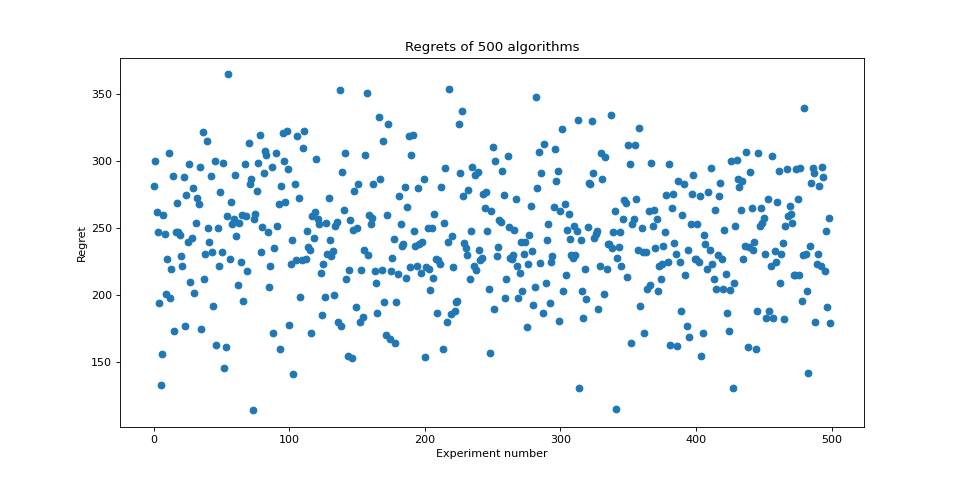

The average regret of 500 experiments is 243.536


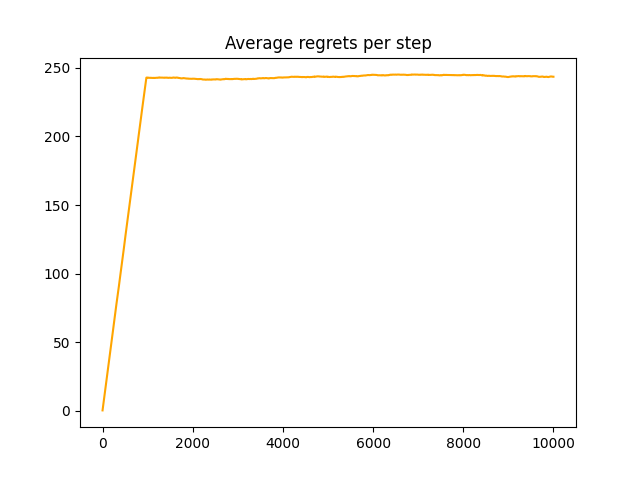

In [24]:
num_experiments = 500
num_bandits = 2
num_steps = 10000
mu_1= 1/2
delta= 1/4
mu_2= mu_1 + delta 
arr= np.array([[mu_1, mu_2]])
means = np.repeat(arr, num_experiments, axis= 0) # The mean for a two-armed bandit. 
agent = ETC_Agent(np.zeros((num_experiments,num_bandits)), np.zeros((1, num_experiments)), num_steps)

ETC_optimality, ETC_scores, cum_regret, regret = run_experiment_new(agent, num_experiments, num_bandits, num_steps, means,  1)

plt.figure(figsize=(12,6), dpi=80, facecolor='w', edgecolor='k')
plt.scatter([i for i in range(num_experiments)], cum_regret)
plt.title("Regrets of 500 algorithms")
plt.ylabel("Regret")
plt.xlabel("Experiment number")
plt.show()
# print(cum_regret.shape) # (1, 500)
print(f"The average regret of {num_experiments} experiments is {regret}")

We can see that when the exploitation stage starts as we start exploiting the best arm and the regret stagnates. We also see that the value is around 243 which is also what we got as average regret of the 500 iterations of the algorithm. 

### B2

Repeat the above for various values of $\Delta \in \{0.05, 0.1, 0.2, 0.3, 0.4, 0.45\}$ and plot the estimated regret as a function of $\Delta$ and verify whether it satisfies the regret upper bound we derived in class. `[5 Marks]`

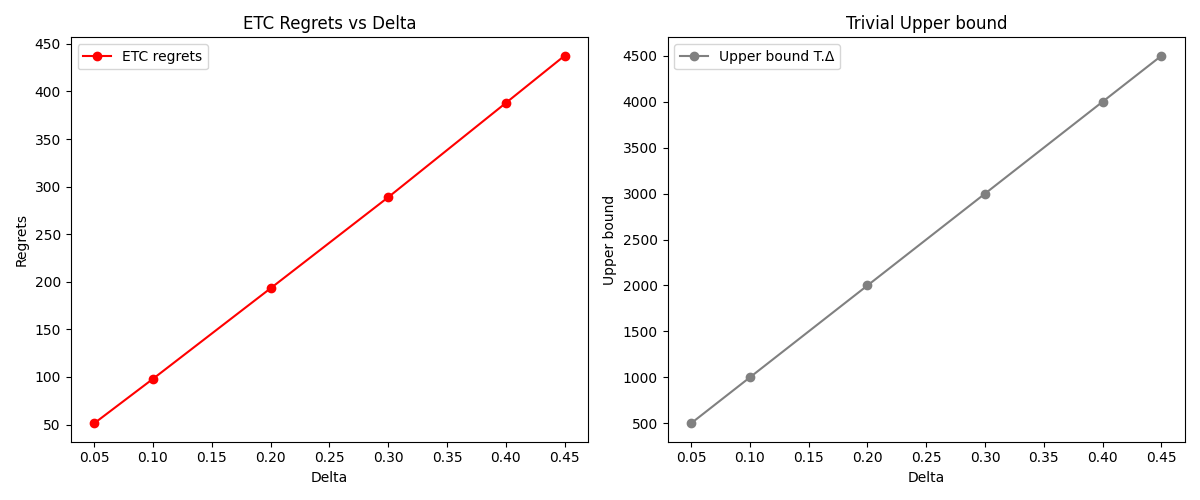

We can see that the regret is bounded by the threshold T^2/3*logT^1/3= 972


In [25]:
# write your code for the above part here
del_arr= [0.05, 0.1, 0.2, 0.3, 0.4, 0.45] 
del_regrets= [] # To store the regret for each value of delta in del_arr
num_steps= 10000
num_experiments = 500
num_bandits = 2
mu_1= 1/2


for delta in del_arr:	
	mu_2= mu_1 + delta 
	arr= np.array([[mu_1, mu_2]])
	means = np.repeat(arr, num_experiments, axis= 0) # The mean for a two-armed bandit. 
	agent = ETC_Agent(np.zeros((num_experiments,num_bandits)), np.zeros((1, num_experiments)), num_steps)
	ETC_optimality, ETC_scores, cum_regret, regret = run_experiment_new(agent, num_experiments, num_bandits, num_steps, means)
	del_regrets.append(regret)
 
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot ETC Regrets vs Delta
axs[0].plot(del_arr, del_regrets, color='red', marker='o', label='ETC regrets')
axs[0].set_title('ETC Regrets vs Delta')
axs[0].set_xlabel('Delta')
axs[0].set_ylabel('Regrets')
axs[0].legend()

# Plot Trivial Upper bound
axs[1].plot(del_arr, [i * num_steps for i in del_arr], color='grey', marker='o', label='Upper bound T.Δ')
axs[1].set_title('Trivial Upper bound')
axs[1].set_xlabel('Delta')
axs[1].set_ylabel('Upper bound')
axs[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()
print(f"We can see that the regret is bounded by the threshold T^2/3*logT^1/3= {int((num_steps**(2/3))*(np.log(num_steps))**(1/3))}")

The maximum regret is lesser than 500, and satisfies our upper bound O(T^2/3 logT^1/3)= 972 and also the trivial upper bound of $T.\Delta$ as can be seen in the right graph. 

### B3 
Repeat the experiment with the UCB algorithm and plot the comparison with ETC. `[10 Marks]`

First we define the agent. 

In [26]:
class UCB_Agent:
    def __init__(self, reward_estimates, cum_reward , T):
        """
        Similar to ETC Agent in terms of initialization. 
        Added a variable playcounts which is used in the UCB algorithm. 
        """
        
        # Reward estimates shape is (num_experiments, num_bandits)

        assert len(reward_estimates.shape) == 2

        self.num_bandits = reward_estimates.shape[1]
        self.num_experiments = reward_estimates.shape[0]
        self.reward_estimates = reward_estimates.astype(np.float64)
        self.cum_reward = cum_reward.astype(np.float64)
        self.action_count = np.zeros(reward_estimates.shape)
        self.rewards= []
        self.best_arm= np.full(shape= (num_experiments,), fill_value=-1)
        self.playcounts= (np.zeros(reward_estimates.shape)) # used to keep count of how many times each arm has been played to maintain upper bound 
        self.num_steps= T
        
    def get_action(self, round):
        action= np.full((num_experiments,), -1) # an initialization of action
        if(np.any(self.playcounts==0)): # if any of the playcounts are zero then play that first. 
            # we will essentially enter this and randomly choose arms until every arm has been played at least once. 
            for i in range(self.num_experiments):
                ind= list(np.where(self.playcounts[i]==0)) # this is all the arms that have not been played yet 
                action[i]= np.random.choice(ind[0])    # choose one of those arms randomly 
        else:
            # use UCB Algorithm, choose action with highest upper bound with c= 3/2 
            action = argmax(self.reward_estimates+ np.sqrt(1.5*np.log(self.num_steps)/self.playcounts))
        # Add a 1 to each action selected in the action count
        self.action_count[np.arange(self.num_experiments), action] += 1
        # print(f"action in round {round} is {action}")
        return action, _

    def update_estimates(self, reward, action):
        self.cum_reward += reward # same as ETC Agent 
        temp= self.cum_reward.copy()
        self.rewards.append(temp)
        n = self.action_count[np.arange(self.num_experiments), action]
        prev_reward_estimates = self.reward_estimates[np.arange(self.num_experiments), action]
        # Update the reward estimates incementally
        self.reward_estimates[np.arange(self.num_experiments), action] = inc_avg(prev_reward_estimates,reward,n)
        prev_playcounts= self.playcounts[np.arange(self.num_experiments), action]
        self.playcounts[np.arange(self.num_experiments), action]= prev_playcounts + 1 # Update the playcounts and increment the arms we played. 

The code below runs UCB in isolation simply to see its working, without comparison with ETC. It also plots the regret of each of the 500 experiments as points on a scatter plot for $\Delta= 0.25$

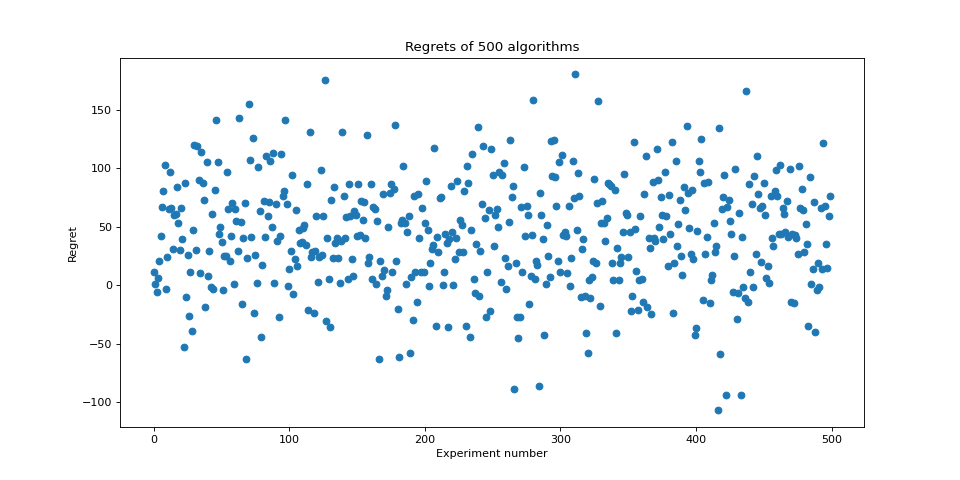

The average regret of 500 experiments is 43.134


In [27]:
num_experiments = 500
num_bandits = 2
num_steps = 10000
mu_1= 1/2
delta= 1/4
mu_2= mu_1 + delta 
arr= np.array([[mu_1, mu_2]])
means = np.repeat(arr, num_experiments, axis= 0) # The mean for a two-armed bandit. 

agent = UCB_Agent(np.zeros((num_experiments,num_bandits)), np.zeros((1, num_experiments)), num_steps)

UCB_optimality, UCB_scores, cum_regret, regret = run_experiment_new(agent, num_experiments, num_bandits, num_steps, means)
plt.figure(figsize=(12,6), dpi=80, facecolor='w', edgecolor='k')
plt.scatter([i for i in range(num_experiments)], cum_regret)
plt.title("Regrets of 500 algorithms")
plt.ylabel("Regret")
plt.xlabel("Experiment number")
plt.show()
# print(cum_regret.shape) # (1, 500)
print(f"The average regret of {num_experiments} experiments is {regret}")

### B3 
Repeat the experiment with the UCB algorithm and plot the comparison with ETC. `[10 Marks]`

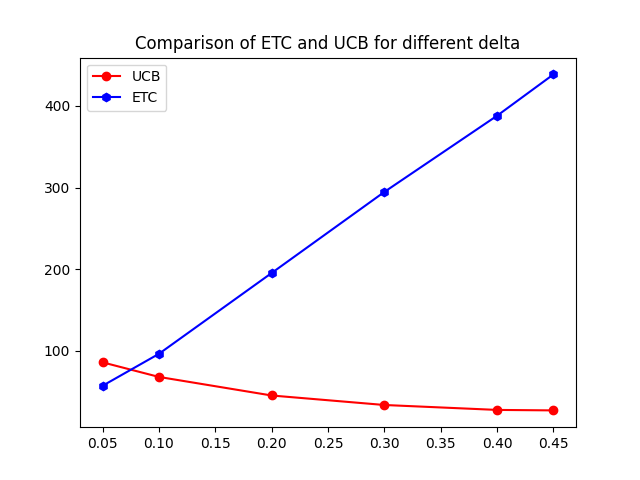

We can see that the regret is bounded by the threshold T^2/3*logT^1/3= 972


In [28]:
# write your code for the above part here
del_arr= [0.05, 0.1, 0.2, 0.3, 0.4, 0.45]
UCB_del_regrets= [] # To store UCB regrets 
ETC_del_regrets= [] # To store ETC regrets 
num_steps= 10000
num_experiments = 500
num_bandits = 2
mu_1= 1/2


for delta in del_arr:	
	mu_2= mu_1 + delta 
	arr= np.array([[mu_1, mu_2]])
	means = np.repeat(arr, num_experiments, axis= 0) # The mean for a two-armed bandit. 
	# We create the agent and run the experiment for both UCB and ETC below. 
	UCB_agent = UCB_Agent(np.zeros((num_experiments,num_bandits)), np.zeros((1, num_experiments)), num_steps)
	UCB_optimality, UCB_scores, UCB_cum_regret, UCB_regret = run_experiment_new(UCB_agent, num_experiments, num_bandits, num_steps, means)
	ETC_agent = ETC_Agent(np.zeros((num_experiments,num_bandits)), np.zeros((1, num_experiments)), num_steps)
	ETC_optimality, ETC_scores, ETC_cum_regret, ETC_regret = run_experiment_new(ETC_agent, num_experiments, num_bandits, num_steps, means)
	UCB_del_regrets.append(UCB_regret)
	ETC_del_regrets.append(ETC_regret)

plt.figure()
plt.plot(del_arr, UCB_del_regrets, color= 'red', marker= 'o', label= 'UCB')
plt.plot(del_arr, ETC_del_regrets, color= 'blue', marker= 'h', label= 'ETC')
plt.title('Comparison of ETC and UCB for different delta')
plt.legend()
plt.show()
print(f"We can see that the regret is bounded by the threshold T^2/3*logT^1/3= {int((num_steps**(2/3))*(np.log(num_steps))**(1/3))}")

### B4
(**Bonus**) In the ETC algorithm, assume that we know $\Delta$, and choose a better $m$ as function of $\Delta$ and repeat the experiments and compare with UCB. What did you observe?

Hint: Check how many samples of exploration are required to make $\epsilon < \frac{\Delta}{2}$ with a high probability of $1-\frac{1}{T}$. `[5 Marks]`

In [29]:
from IPython.display import Latex

Hoeffding inequality states that $P(|\mu- \mu_e> \epsilon|)\leq exp(-2\epsilon^2m)$, where $\mu_e$ is estimated sample mean and we have used $\sigma= 1/2$ as the arms rewards are bounded between 0 and 1.<br>
This bound essentially states that $\mu_e$ belongs to the interval $(\mu-\epsilon, \mu + \epsilon)$ with high probability. 
Now, we have good event and bad event when we complete exploration, where a bad event occurs when the above interval fails for either of the two arms.
Using Chernoff bound and union bound, <br>
P(Bad Event)= P(interval for arm a or arm b is wrong) $\leq$ P(interval for arm a is wrong)+ P(interval for arm b is wrong) $\leq 4exp(-2\epsilon^2m) $<br>
As given in the question, if $\epsilon < \Delta/2$ then we have shown in the notes that we will have zero regret in the exploitation phase.<br>
If we set $P(Bad \ Event)= 1/T $ then $P(Good\ Event)= 1- 1/T$, and since we know delta, we can choose m in a way that every time we have good event the condition $\epsilon < \Delta/2$ is true- which makes $\epsilon < \Delta/2$ with a high probability of $1-1/T$ as asked. <br><br>
So when $P(Bad\ Event)= 1/T \rightarrow 4exp(-2\epsilon^2m) = 1/T \rightarrow \epsilon = \sqrt{ln4T/2m}$ <br>
But also $\epsilon < \Delta/2 \rightarrow ln4T/2m < \Delta^2/4 \rightarrow m> 2ln4T/\Delta^2$ <br>

So using a value of m greater than $2ln4T/\Delta^2$ is sufficient to have $\epsilon < \Delta/2$ with high probability $1-1/T$, and this is used to plot the new behaviour of ETC(rather than the old bound of $m= T^{2/3} logT^{1/3})$


The old and new thresholds for m are 972 and 8477 respectively for delta= 0.05
The old and new thresholds for m are 972 and 2119 respectively for delta= 0.1
The old and new thresholds for m are 972 and 529 respectively for delta= 0.2
The old and new thresholds for m are 972 and 235 respectively for delta= 0.3
The old and new thresholds for m are 972 and 132 respectively for delta= 0.4
The old and new thresholds for m are 972 and 104 respectively for delta= 0.45


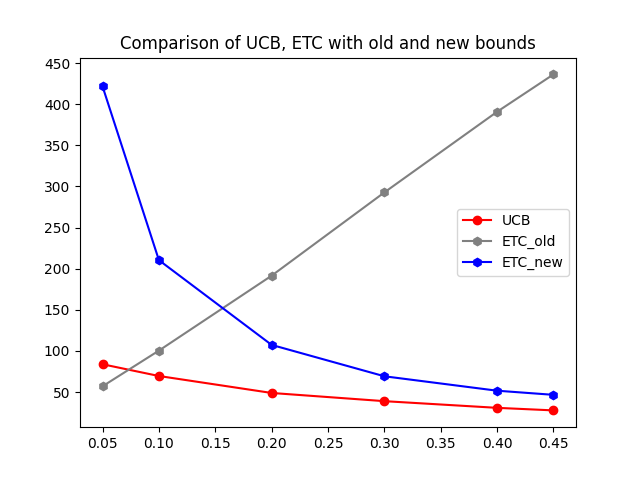

In [30]:
# write your code for the above part here
del_arr= [0.05, 0.1, 0.2, 0.3, 0.4, 0.45]
UCB_del_regrets= []
ETC_del_regrets= []
ETC_del_regrets_tighter_bound= []
num_steps= 10000
num_experiments = 500
num_bandits = 2
mu_1= 1/2


for delta in del_arr:	
	mu_2= mu_1 + delta 
	arr= np.array([[mu_1, mu_2]])
	means = np.repeat(arr, num_experiments, axis= 0) # The mean for a two-armed bandit. 
	UCB_agent = UCB_Agent(np.zeros((num_experiments,num_bandits)), np.zeros((1, num_experiments)), num_steps)
	UCB_optimality, UCB_scores, UCB_cum_regret, UCB_regret = run_experiment_new(UCB_agent, num_experiments, num_bandits, num_steps, means)
	ETC_agent = ETC_Agent(np.zeros((num_experiments,num_bandits)), np.zeros((1, num_experiments)), num_steps)
	ETC_optimality, ETC_scores, ETC_cum_regret, ETC_regret = run_experiment_new(ETC_agent, num_experiments, num_bandits, num_steps, means)
	ETC_agent1 = ETC_Agent(np.zeros((num_experiments,num_bandits)), np.zeros((1, num_experiments)), num_steps) # Agent to run with new bounds 
	old_threshold= ETC_agent1.threshold
	ETC_agent1.threshold= int((2*np.log(4*num_steps))/delta**2)
	# Set a new threshold as derived above and use it instead of the old threshold. 
	print(f"The old and new thresholds for m are {old_threshold} and {ETC_agent1.threshold} respectively for delta= {delta}")
	ETC_optimality1, ETC_scores1, ETC_cum_regret1, ETC_regret1 = run_experiment_new(ETC_agent1, num_experiments, num_bandits, num_steps, means)
	UCB_del_regrets.append(UCB_regret)
	ETC_del_regrets.append(ETC_regret)
	ETC_del_regrets_tighter_bound.append(ETC_regret1)

plt.figure()
plt.plot(del_arr, UCB_del_regrets, color= 'red', marker= 'o', label= 'UCB')
plt.plot(del_arr, ETC_del_regrets, color= 'grey', marker= 'h', label= 'ETC_old')
plt.plot(del_arr, ETC_del_regrets_tighter_bound, color= 'blue', marker= 'h', label= 'ETC_new')
plt.title('Comparison of UCB, ETC with old and new bounds')
plt.legend()
plt.show()

This tighter bound on m which ensures that we select the best arm after exploration is over gives much better regrets in the ETC algorithm. We can also see how it becomes more effective for larger delta, since we can stop exploring and start exploiting the best arm much sooner. For example, at delta= 0.4, we start exploiting the best arm after 115 steps, giving nearly 850 additional steps to exploit and hence giving much lower regret than before. However, at small delta, the earlier algorithm was performing better because it becomes harder to enforce $\epsilon< \Delta/2$ when $\Delta$ becomes smaller.